Objective

Estimate the embodied carbon emissions (kg CO₂/m³) of each concrete mix using the material quantities and published carbon emission factors.

In [20]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [21]:
# Load dfset containing cost information
df = pd.read_csv("../results/concrete_with_cost.csv")

print("dfset Shape:", df.shape)
df.head()



dfset Shape: (1005, 10)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48


In [22]:
# Load Carbon Reference Table
carbon_reference = pd.read_csv("../dataset/carbon_emission_reference.csv")

carbon_reference

,Material,Unit,Emission_Factor_kgCO2_per_kg
0,Cement,kg,0.9000
1,Blast Furnace Slag,kg,0.0520
2,Fly Ash,kg,0.0270
3,Water,kg,0.0003
4,Superplasticizer,kg,1.8800
5,Coarse Aggregate,kg,0.0080
6,Fine Aggregate,kg,0.0050


In [23]:
#Create Dictionary
carbon_dict = dict(zip(
    carbon_reference["Material"],
    carbon_reference["Emission_Factor_kgCO2_per_kg"]
))

carbon_dict

{'Cement': 0.9,
 'Blast Furnace Slag': 0.052,
 'Fly Ash': 0.027,
 'Water': 0.0003,
 'Superplasticizer': 1.88,
 'Coarse Aggregate': 0.008,
 'Fine Aggregate': 0.005}

In [24]:
# Calculate Carbon Emission
df["Carbon_Emission_kgCO2"] = (
    df["Cement"] * carbon_dict["Cement"] +
    df["Blast Furnace Slag"] * carbon_dict["Blast Furnace Slag"] +
    df["Fly Ash"] * carbon_dict["Fly Ash"] +
    df["Water"] * carbon_dict["Water"] +
    df["Superplasticizer"] * carbon_dict["Superplasticizer"] +
    df["Coarse Aggregate"] * carbon_dict["Coarse Aggregate"] +
    df["Fine Aggregate"] * carbon_dict["Fine Aggregate"]
)

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,Material_Cost_INR,Carbon_Emission_kgCO2
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,6822.10,502.4486
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,6840.10,502.5686
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,4977.55,317.1544
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,4977.55,317.1544
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,4094.48,197.6371


In [25]:
# Carbon Statistics
df["Carbon_Emission_kgCO2"].describe()

count    1005.000000
mean      279.069509
std        93.238065
min       111.619600
25%       198.852500
50%       265.220130
75%       332.055170
max       542.513840
Name: Carbon_Emission_kgCO2, dtype: float64

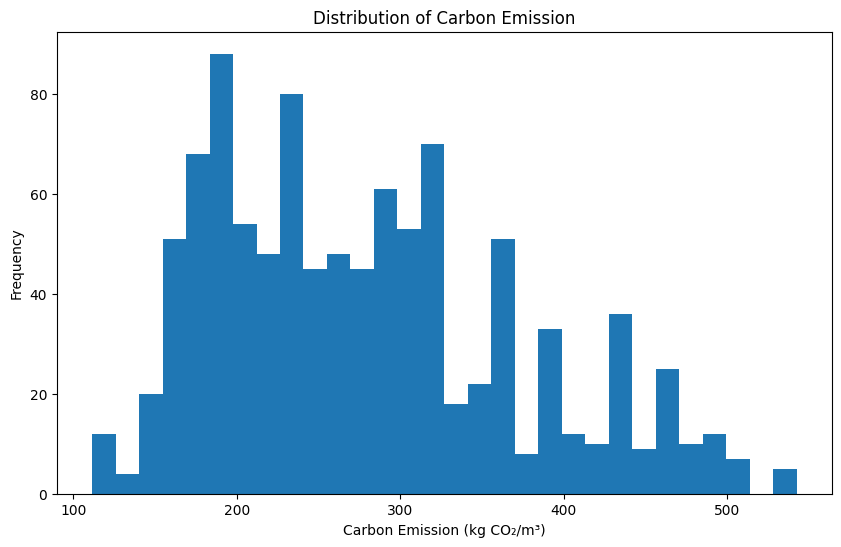

In [26]:
# Histogram
plt.hist(df["Carbon_Emission_kgCO2"], bins=30)

plt.title("Distribution of Carbon Emission")

plt.xlabel("Carbon Emission (kg CO₂/m³)")

plt.ylabel("Frequency")

plt.show()

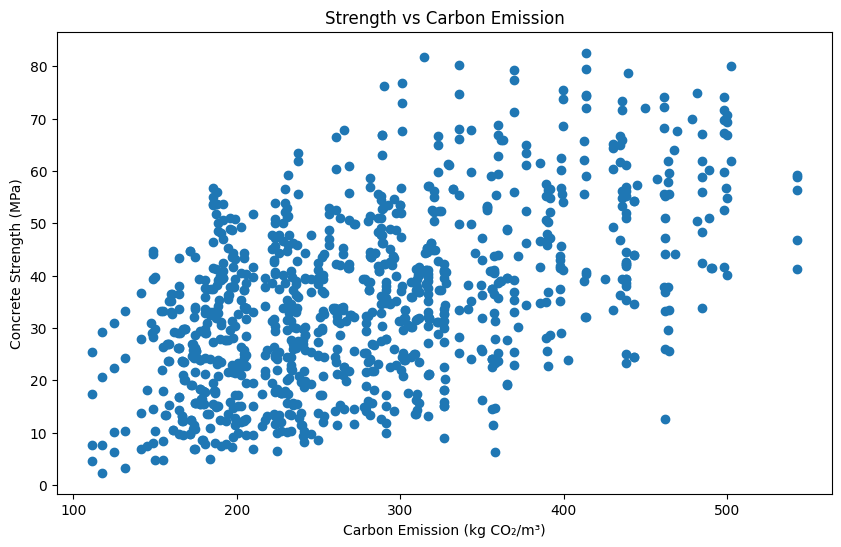

In [27]:
# Strength vs Carbon Emission
plt.scatter(
    df["Carbon_Emission_kgCO2"],
    df["Strength"]
)

plt.xlabel("Carbon Emission (kg CO₂/m³)")
plt.ylabel("Concrete Strength (MPa)")
plt.title("Strength vs Carbon Emission")

plt.show()

In [28]:
# Save Results
df.to_csv(
    "../results/concrete_with_carbon.csv",
    index=False
)

print("Carbon emission dataset saved successfully!")

Carbon emission dataset saved successfully!
